In [7]:
# Where the plots are saved
path_figures = "../images"

# Quickstart

<Figure size 640x480 with 0 Axes>

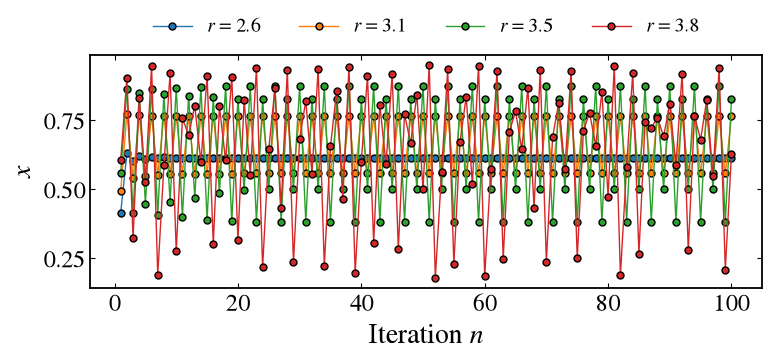

In [109]:
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="logistic map")
parameter_values = [2.6, 3.1, 3.5, 3.8]
total_time = 100

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(8, 4))
for r in parameter_values:
    trajectory = system.trajectory(0.2, total_time, parameters=[r])
    ax.plot(range(1, total_time + 1), trajectory, "o-", label=f"$r = {r}$")

ax.set_xlabel("Iteration $n$")
ax.set_ylabel("$x$")
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.tight_layout()
plt.savefig(f"{path_figures}/quickstart_logistic.png", dpi=400, bbox_inches="tight")

In [110]:
system.info["parameters"]

['r']

In [111]:
system.info["equation"]

<IPython.core.display.Math object>

In [112]:
system.info["equation_readable"]

'xₙ₊₁ = rxₙ(1−xₙ)'

# Creating a discrete dynamical system

## Using a built-in model

In [113]:
from pynamicalsys import DiscreteDynamicalSystem as dds

for model in dds.available_models():
    print(model)

standard map
unbounded standard map
henon map
lozi map
rulkov map
logistic map
standard nontwist map
extended standard nontwist map
leonel map
4d symplectic map


The Chirikov-Taylor standard map is

$$
\begin{aligned}
    y_{n+1} &= y_n + \frac{k}{2\pi}\sin(2\pi x_n) \pmod{1}, \\
    x_{n+1} &= x_n + y_{n+1} \pmod{1}.
\end{aligned}
$$

In [114]:
system = dds(model="standard map")
system.info["parameters"]

['k']

In [115]:
system.info["equation"]

<IPython.core.display.Math object>

## Creating a custom map

In [ ]:
import numpy as np
from numba import njit
from pynamicalsys import DiscreteDynamicalSystem as dds


@njit
def standard_map(state, parameters):
    x, y = state
    k = parameters[0]
    y_next = (y + k * np.sin(2.0 * np.pi * x) / (2.0 * np.pi)) % 1.0
    x_next = (x + y_next) % 1.0
    return np.array([x_next, y_next])


@njit
def standard_map_jacobian(state, parameters, mapping):
    x, _ = state
    k = parameters[0]
    derivative = k * np.cos(2.0 * np.pi * x)
    return np.array(
        [
            [1.0 + derivative, 1.0],
            [derivative, 1.0],
        ]
    )

In [117]:
system = dds(
    mapping=standard_map,
    jacobian=standard_map_jacobian,
    system_dimension=2,
    parameters=[1.5],
)

In [118]:
system = dds(
    mapping=standard_map,
    jacobian=standard_map_jacobian,
    system_dimension=2,
    number_of_parameters=1,
)

next_state = system.step([0.1, 0.2], parameters=[1.5])

## Managing parameters

In [119]:
system.set_parameters([1.5])
system.get_parameters()

array([1.5])

In [120]:
stored_result = system.step([0.1, 0.2])
override_result = system.step([0.1, 0.2], parameters=[0.5])
system.get_parameters()

array([1.5])

# Generating trajectories

## A single trajectory

In [121]:
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="standard map")
system.set_parameters([1.5])

initial_state = [0.2, 0.5]
total_time = 5_000_000
trajectory = system.trajectory(initial_state, total_time)

<Figure size 640x480 with 0 Axes>

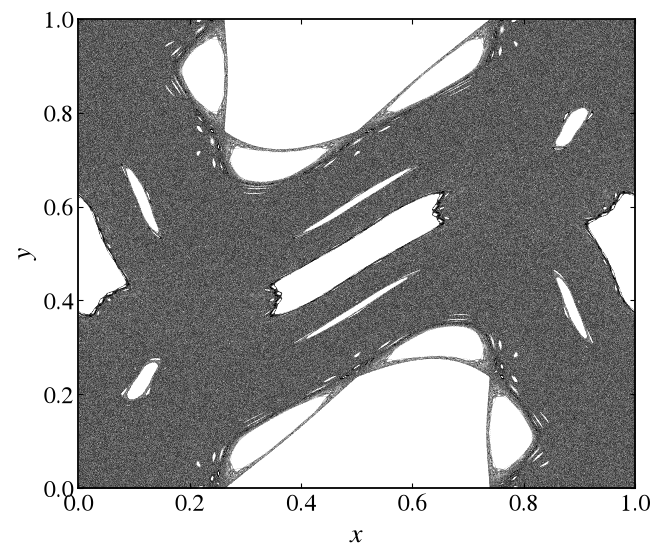

In [122]:
ps = PlotStyler(markersize=0.1, markeredgewidth=0)
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(trajectory[:, 0], trajectory[:, 1], "ko")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
fig.tight_layout()
plt.savefig(f"{path_figures}/standard_map_trajectory.png", dpi=400, bbox_inches="tight")

## An ensemble of trajectories

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="standard map")
system.set_parameters([1.5])

rng = np.random.default_rng(13)
num_initial_conditions = 20
total_time = 100_000
initial_conditions = rng.uniform(
    0.0,
    1.0,
    size=(num_initial_conditions, 2),
)

trajectories = system.trajectory(initial_conditions, total_time)
trajectories = trajectories.reshape(
    num_initial_conditions,
    total_time,
    2,
)

<Figure size 640x480 with 0 Axes>

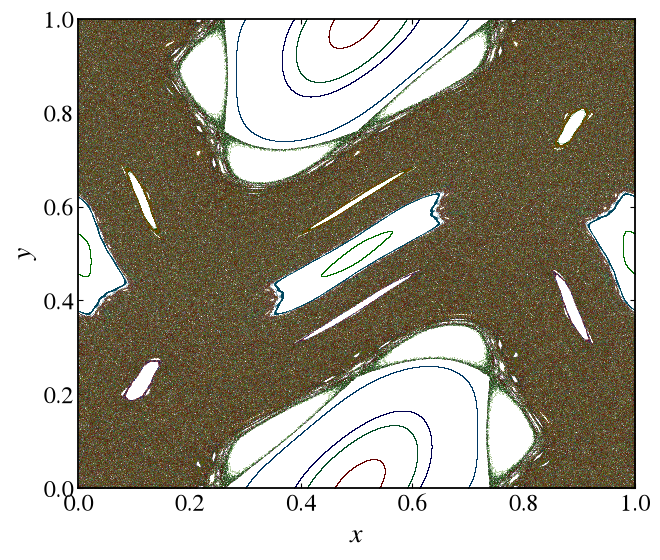

In [ ]:
colors = plt.cm.nipy_spectral(np.linspace(0.0, 1.0, num_initial_conditions))

ps = PlotStyler(markersize=0.3, markeredgewidth=0)
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 6))
for trajectory, color in zip(trajectories, colors):
    ax.plot(trajectory[:, 0], trajectory[:, 1], "o", color=color)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_rand_trajectories.png", dpi=400, bbox_inches="tight"
)

## Discarding a transient

In [125]:
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="henon map")
system.set_parameters([1.4, 0.3])

initial_state = [0.2, 0.2]
total_time = 100_000
transient_time = 10_000
trajectory = system.trajectory(
    initial_state,
    total_time,
    transient_time=transient_time,
)

<Figure size 640x480 with 0 Axes>

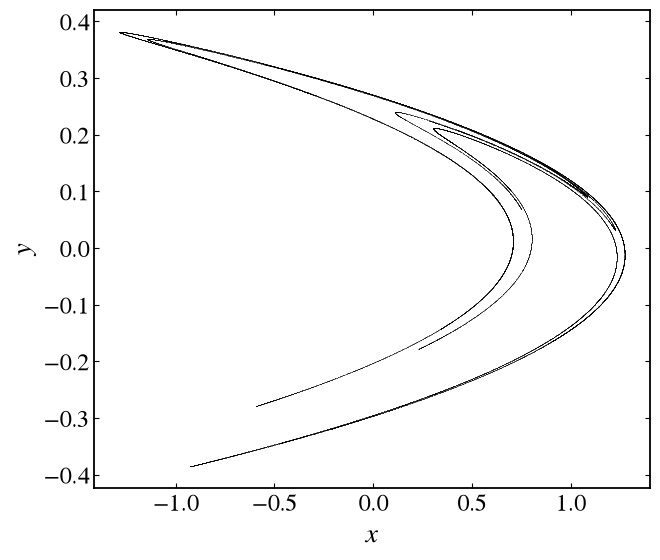

In [126]:
ps = PlotStyler(markersize=0.2, markeredgewidth=0)
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(trajectory[:, 0], trajectory[:, 1], "ko")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_map_trajectory.png", dpi=400, bbox_inches="tight")

# Bifurcation diagrams

## Logistic map

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="logistic map")
parameter_range = (2.5, 4.0, 3_000)
total_time = 4_000
transient_time = 1_000

parameter_values, bifurcation_values = system.bifurcation_diagram(
    u=0.2,
    param_index=0,
    param_range=parameter_range,
    total_time=total_time,
    transient_time=transient_time,
)

<Figure size 640x480 with 0 Axes>

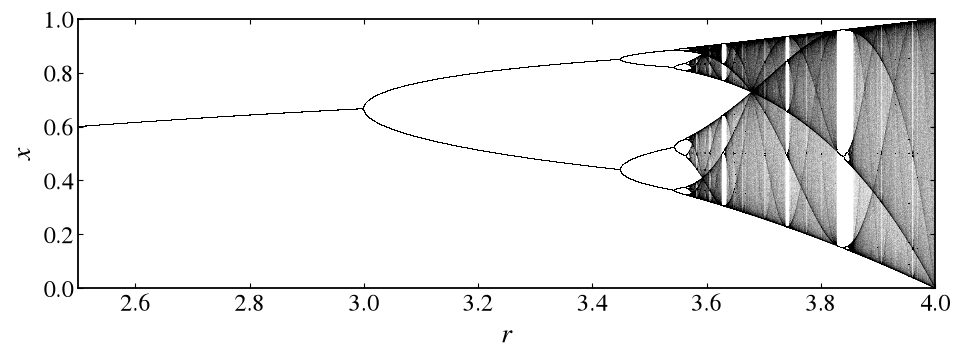

In [ ]:
parameter_plot = np.repeat(
    parameter_values,
    bifurcation_values.shape[1],
)
observable_plot = bifurcation_values.ravel()

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(parameter_plot, observable_plot, color="black", s=0.01, edgecolor="none")
ax.set_xlim(parameter_range[0], parameter_range[1])
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("$r$")
ax.set_ylabel("$x$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/logistic_map_bifurcation_diagram.png", dpi=400, bbox_inches="tight"
)

## Hénon map

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="henon map")
system.set_parameters([0.0, 0.3])

parameter_range = (1.0, 1.4, 3_000)
total_time = 5_000
transient_time = 1_000
parameter_values, bifurcation_values = system.bifurcation_diagram(
    u=[0.2, 0.2],
    param_index=0,
    param_range=parameter_range,
    total_time=total_time,
    transient_time=transient_time,
)

<Figure size 640x480 with 0 Axes>

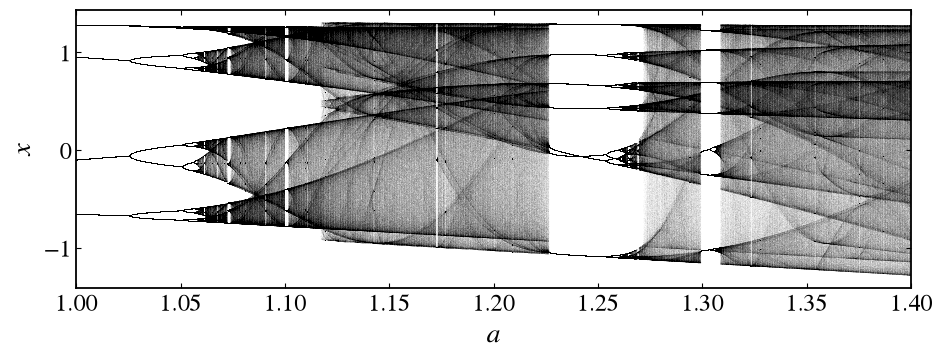

In [ ]:
parameter_plot = np.repeat(
    parameter_values,
    bifurcation_values.shape[1],
)
observable_plot = bifurcation_values.ravel()

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(parameter_plot, observable_plot, color="black", s=0.01, edgecolor="none")
ax.set_xlim(parameter_range[0], parameter_range[1])
ax.set_xlabel("$a$")
ax.set_ylabel("$x$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/henon_map_bifurcation_diagram.png", dpi=400, bbox_inches="tight"
)

# Chaotic indicators

## Lyapunov exponents

### One-dimensional maps

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="logistic map")
parameter_range = (2.5, 4.0, 3_000)
total_time = 5_000
transient_time = 1_000

parameter_values, bifurcation_values = system.bifurcation_diagram(
    u=0.2,
    param_index=0,
    param_range=parameter_range,
    total_time=total_time,
    transient_time=transient_time,
)

lyapunov_exponents = np.array(
    [
        system.lyapunov(
            u=0.2,
            total_time=total_time,
            parameters=r,
            transient_time=transient_time,
        )
        for r in parameter_values
    ]
)

<Figure size 640x480 with 0 Axes>

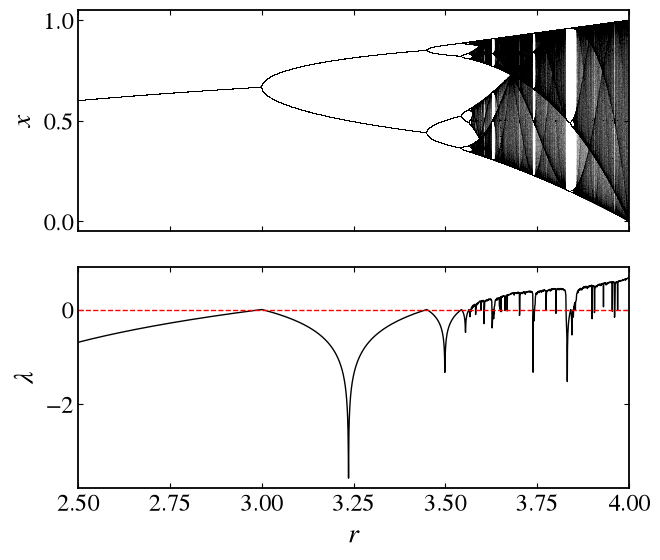

In [132]:
parameter_plot = np.repeat(
    parameter_values,
    bifurcation_values.shape[1],
)
observable_plot = bifurcation_values.ravel()

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].scatter(parameter_plot, observable_plot, color="black", s=0.01, edgecolor="none")
ax[0].set_xlim(parameter_range[0], parameter_range[1])
ax[0].set_ylabel("$x$")
ax[1].plot(parameter_values, lyapunov_exponents, color="black")
ax[1].axhline(0.0, color="red", linestyle="--")
ax[1].set_xlabel("$r$")
ax[1].set_ylabel(r"$\lambda$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/logistic_map_lyapunov_exponents.png", dpi=400, bbox_inches="tight"
)

### Higher-dimensional maps

In [199]:
import numpy as np
from pynamicalsys import DiscreteDynamicalSystem as dds

system = dds(model="henon map")
system.set_parameters([1.4, 0.3])

lyapunov_exponents = system.lyapunov(
    u=[0.1, 0.1],
    total_time=100_000,
    transient_time=1_000,
)

largest_exponent = system.lyapunov(
    u=[0.1, 0.1],
    total_time=100_000,
    transient_time=1_000,
    num_exponents=1,
)

spectrum_sum = np.sum(lyapunov_exponents)
expected_sum = np.log(0.3)
print(f"Spectrum: {lyapunov_exponents}")
print(f"Spectrum sum: {spectrum_sum:.6f}")
print(f"Expected sum: {expected_sum:.6f}")

Spectrum: [ 0.41928213 -1.62325493]
Spectrum sum: -1.203973
Expected sum: -1.203973


### Convergence history

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="4d symplectic map")
system.set_parameters([0.5, 0.1, 0.001])

initial_states = np.array(
    [
        [0.5, 0.0, 0.5, 0.0],
        [3.0, 0.0, 0.5, 0.0],
    ]
)
total_time = 1_000_000
sample_times = np.unique(np.logspace(0, np.log10(total_time), 1_000).astype(int))

histories = np.empty((len(initial_states), len(sample_times), 4))
for i, initial_state in enumerate(initial_states):
    histories[i] = system.lyapunov(
        u=initial_state,
        total_time=total_time,
        return_history=True,
        sample_times=sample_times,
    )

spectra = histories[:, -1, :]
spectrum_sums = np.sum(spectra, axis=1)
print(f"Final spectra:\n{spectra}")
print(f"Spectrum sums: {spectrum_sums}")

Final spectra:
[[ 8.98676229e-06  9.24920790e-06 -8.69827987e-06 -9.53769033e-06]
 [ 9.46539591e-03  2.71437710e-04 -2.70617113e-04 -9.46621651e-03]]
Spectrum sums: [-1.23327997e-18  8.67361738e-18]


<Figure size 640x480 with 0 Axes>

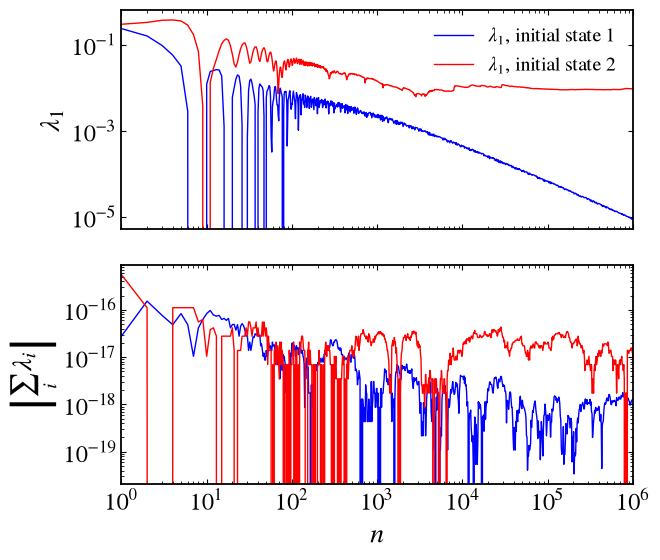

In [202]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].plot(sample_times, histories[0, :, 0], color="blue", label=r"$\lambda_1$, initial state 1")
ax[0].plot(sample_times, histories[1, :, 0], color="red", label=r"$\lambda_1$, initial state 2")
ax[0].set_yscale("log")
ax[0].set_ylabel(r"$\lambda_1$")
ax[0].legend(frameon=False)
ax[1].loglog(sample_times, abs(np.sum(histories[0], axis=1)), color="blue")
ax[1].loglog(sample_times, abs(np.sum(histories[1], axis=1)), color="red")
ax[1].axhline(0.0, color="black", linestyle="--")
ax[1].set_xlim(1, total_time)
ax[1].set_xlabel("$n$")
ax[1].set_ylabel(r"$\left|\sum_i\,\lambda_i\right|$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/4d_symplectic_map_lyapunov_exponents.png",
    dpi=400,
    bbox_inches="tight",
)

### Finite-time exponents

In [197]:
system = dds(model="standard map")
system.set_parameters([1.5])

initial_state = [0.05, 0.05]
total_time = 50_000_000
finite_time = 100
finite_time_exponents, phase_space_points = system.finite_time_lyapunov(
    u=initial_state,
    total_time=total_time,
    finite_time=finite_time,
    num_exponents=1,
    return_points=True,
)

<Figure size 640x480 with 0 Axes>

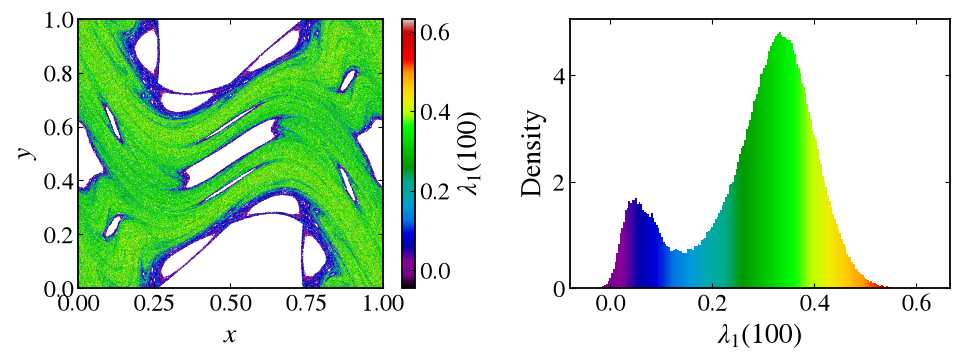

In [198]:
exponent_values = finite_time_exponents[:, 0]
normalization = plt.Normalize(exponent_values.min(), exponent_values.max())
colormap = plt.get_cmap("nipy_spectral")

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
points_plot = ax[0].scatter(
    phase_space_points[:, 0],
    phase_space_points[:, 1],
    c=exponent_values,
    s=0.2,
    edgecolor="none",
    cmap=colormap,
    norm=normalization,
)
ax[0].set_xlim(0.0, 1.0)
ax[0].set_ylim(0.0, 1.0)
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
fig.colorbar(points_plot, ax=ax[0], label=rf"$\lambda_1({finite_time})$")

density, bin_edges, patches = ax[1].hist(exponent_values, bins=200, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
for center, patch in zip(bin_centers, patches):
    patch.set_facecolor(colormap(normalization(center)))
ax[1].set_xlabel(rf"$\lambda_1({finite_time})$")
ax[1].set_ylabel("Density")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_finite_time_lyapunov_exponents.png",
    dpi=400,
    bbox_inches="tight",
)

## Covariant Lyapunov vectors

Lyapunov exponents quantify average rates of expansion and contraction, while covariant Lyapunov vectors identify the intrinsic local tangent directions associated with those rates. Unlike the orthonormal vectors generated during the QR calculation of the spectrum, CLVs are generally not orthogonal and transform covariantly with the tangent dynamics. Practical algorithms for computing them were introduced independently by [Ginelli et al. (2007)](https://doi.org/10.1103/PhysRevLett.99.130601) and [Wolfe and Samelson (2007)](https://doi.org/10.1111/j.1600-0870.2007.00234.x).

### Computing the vectors

The example uses the three-dimensional generalized Hénon map studied by [Kuptsov and Kuznetsov (2018)](https://doi.org/10.1134/S1560354718070079):

$$
\begin{aligned}
x_{n+1} &= y_n, \\
y_{n+1} &= z_n, \\
z_{n+1} &= b x_n + c y_n + a z_n - z_n^2.
\end{aligned}
$$

The analytical Jacobian carries the third **mapping** argument required by the common Jacobian signature, even though it does not use it.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

@njit
def henon_map_3d(u, parameters):
    a, b, c = parameters
    x, y, z = u
    x_new = y
    y_new = z
    z_new = b * x + c * y + a * z - z**2

    return np.array([x_new, y_new, z_new])

@njit
def henon_map_3d_jacobian(u, parameters, mapping):
    a, b, c = parameters
    x, y, z = u

    return np.array(
        [
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 1.0],
            [b, c, a - 2.0 * z],
        ]
    )

system = dds(
    mapping=henon_map_3d,
    jacobian=henon_map_3d_jacobian,
    system_dimension=3,
    parameters=[-1.11, 0.7, 0.77],
)

In [9]:
initial_state = [0.05, 0.05, 0.05]
total_time = 100_000
transient_time = 10_000
warmup_time = 10_000
tail_time = 10_000

clvs, trajectory = system.CLV(
    u=initial_state,
    total_time=total_time,
    transient_time=transient_time,
    warmup_time=warmup_time,
    tail_time=tail_time,
)
print(clvs.shape)
print(trajectory.shape)

(100001, 3, 3)
(100001, 3)


### Angles between tangent subspaces

Following Kuptsov and Kuznetsov (2018), $\theta_1$ is the minimum principal angle between $\operatorname{span}(\mathbf{v}_1)$ and $\operatorname{span}(\mathbf{v}_2, \mathbf{v}_3)$, while $\theta_2$ is the minimum principal angle between $\operatorname{span}(\mathbf{v}_1, \mathbf{v}_2)$ and $\operatorname{span}(\mathbf{v}_3)$. The second angle therefore separates the center-unstable subspace $E^{cu}$ from the strongly stable subspace $E^s$. The two columns are returned in this order. With the default **use_abs=True**, vector orientation is ignored and the angles lie between $0$ and $\pi/2$.

In [10]:
angles, angle_trajectory = system.CLV_angles(
    u=initial_state,
    total_time=total_time,
    subspaces=(
        ([0], [1, 2]),
        ([0, 1], [2]),
    ),
    transient_time=transient_time,
    warmup_time=warmup_time,
    tail_time=tail_time,
)
print(angles.shape)
print(angle_trajectory.shape)

(100001, 2)
(100001, 3)


<Figure size 640x480 with 0 Axes>

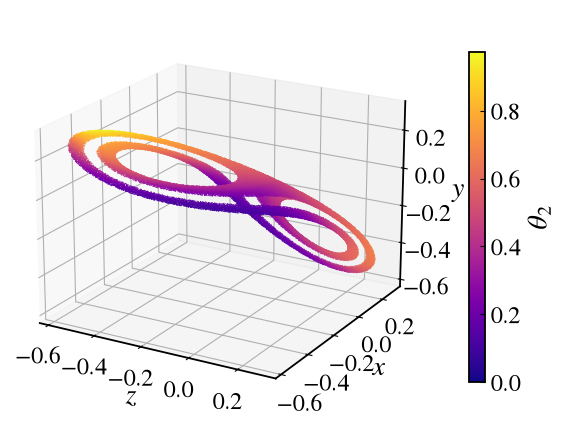

In [27]:
points = angle_trajectory
theta_2 = angles[:, 1]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(
    figsize=(6, 5),
    subplot_kw={"projection": "3d"},
)
points_plot = ax.scatter(
    points[:, 2],
    points[:, 0],
    points[:, 1],
    c=theta_2,
    cmap="plasma",
    vmin=0.0,
    vmax=theta_2.max(),
    s=0.5,
    edgecolor="none",
)
plt.tight_layout()
ax.set_xlabel("$z$")
ax.set_ylabel("$x$")
ax.set_zlabel("$y$")
ax.view_init(elev=20, azim=-60)
colorbar = fig.colorbar(points_plot, ax=ax, shrink=0.75, pad=0.08)
colorbar.set_label(r"$\theta_2$")
plt.savefig(
    f"{path_figures}/generalized_henon_map_clv_angles.png",
    dpi=400,
    bbox_inches="tight",
)

### Angle distributions

Reproduce Fig. 19(a) of Kuptsov and Kuznetsov (2018) by estimating the distributions of $\theta_1$ and $\theta_2$ from their full histories. A distribution that remains separated from zero indicates that the corresponding tangent subspaces stay transversal along the sampled trajectory. The optional **window_time** argument can instead return window-averaged angles and the initial state of each window, but averaging can hide isolated near-tangencies.

<Figure size 640x480 with 0 Axes>

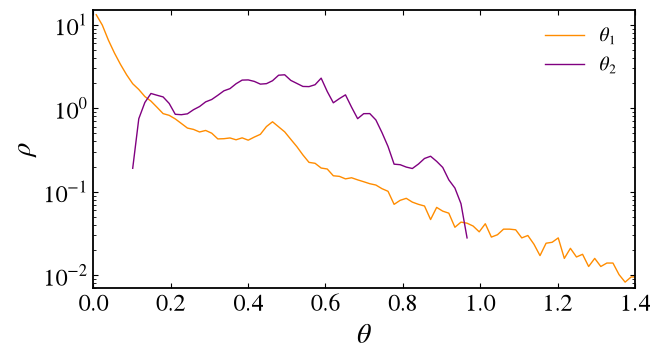

In [18]:
bins = np.linspace(0.0, np.pi / 2, 101)
angle_labels = [
    r"$\theta_1$",
    r"$\theta_2$",
]
colors = ["darkorange", "purple"]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
for i, label in enumerate(angle_labels):
    density, edges = np.histogram(angles[:, i], bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    centers = centers[density > 0]
    density = density[density > 0]
    ax.plot(centers, density, color=colors[i], label=label)
ax.set_xlim(0.0, 1.4)
ax.set_xticks(np.arange(0.0, 1.41, 0.2))
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\rho$")
ax.set_yscale("log")
ax.set_ylim(0.7e-2, 1.5e1)
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/generalized_henon_map_clv_angle_distribution.png",
    dpi=400,
    bbox_inches="tight",
)

## Alignment indices

### Smaller Alignment Index

In [236]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="4d symplectic map")
system.set_parameters([0.5, 0.1, 0.001])

initial_states = np.array(
    [
        [0.5, 0.0, 0.5, 0.0],
        [3.0, 0.0, 0.5, 0.0],
    ]
)
total_time = 1_000_000
sample_times = np.unique(np.logspace(0, np.log10(total_time), 1_000).astype(int))
tol = 1e-16
seed = 1312

sali_histories = np.empty((len(initial_states), len(sample_times)))
for i, initial_state in enumerate(initial_states):
    sali_histories[i] = system.SALI(
        u=initial_state,
        total_time=total_time,
        return_history=True,
        sample_times=sample_times,
        tol=tol,
        seed=seed,
    )

<Figure size 640x480 with 0 Axes>

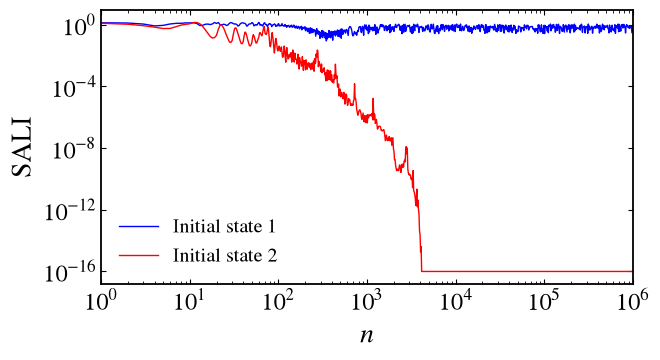

In [237]:
colors = ["blue", "red"]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
for i in range(len(initial_states)):
    ax.loglog(
        sample_times,
        np.maximum(sali_histories[i], tol),
        color=colors[i],
        label=f"Initial state {i + 1}",
    )
ax.set_xlim(1, total_time)
ax.set_xlabel("$n$")
ax.set_ylabel(r"$\mathrm{SALI}$")
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/4d_symplectic_map_sali.png",
    dpi=400,
    bbox_inches="tight",
)

### Generalized Alignment Index

<Figure size 640x480 with 0 Axes>

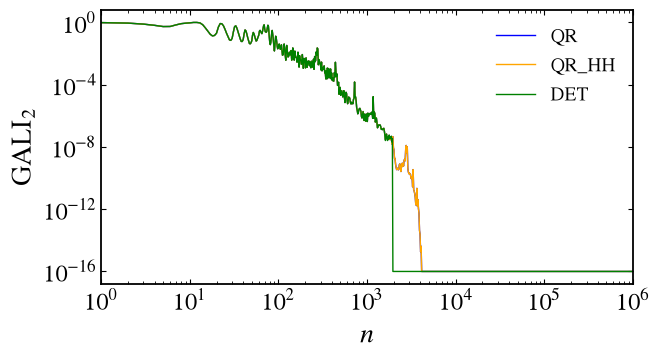

In [238]:
colors = ["blue", "orange", "green"]
gali_methods = ["QR", "QR_HH", "DET"]
k = 2
gali_method_histories = np.empty((len(gali_methods), len(sample_times)))
for i, method in enumerate(gali_methods):
    gali_method_histories[i] = system.GALI(
        u=initial_states[1],
        total_time=total_time,
        k=k,
        return_history=True,
        sample_times=sample_times,
        method=method,
        tol=tol,
        seed=seed,
    )

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
for i, method in enumerate(gali_methods):
    ax.loglog(
        sample_times,
        np.maximum(gali_method_histories[i], tol),
        label=method,
        color=colors[i],
    )
ax.set_xlim(1, total_time)
ax.set_xlabel("$n$")
ax.set_ylabel(fr"$\mathrm{{GALI}}_{k}$")
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/4d_symplectic_map_gali_methods.png",
    dpi=400,
    bbox_inches="tight",
)

### Generalized Alignment Index for different values of $k$

In [239]:
k_values = np.array([2, 3, 4])
gali_histories = np.empty((len(initial_states), len(sample_times), len(k_values)))
for i, initial_state in enumerate(initial_states):
    for j, k in enumerate(k_values):
        gali_histories[i, :, j] = system.GALI(
            u=initial_state,
            total_time=total_time,
            k=k,
            return_history=True,
            sample_times=sample_times,
            method="QR_HH",
            tol=tol,
            seed=seed,
        )

<Figure size 640x480 with 0 Axes>

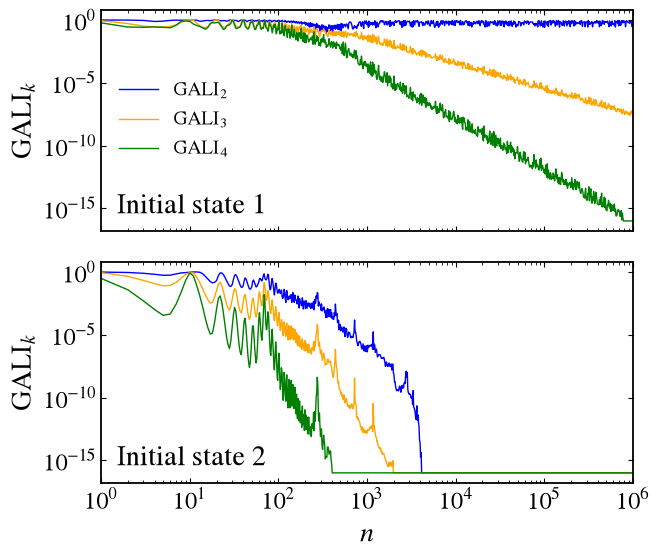

In [240]:
colors = ["blue", "orange", "green"]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)
for i in range(len(initial_states)):
    for j, k in enumerate(k_values):
        ax[i].loglog(
            sample_times,
            np.maximum(gali_histories[i, :, j], tol),
            color=colors[j],
            label=rf"$\mathrm{{GALI}}_{k}$",
        )
    ax[i].set_ylabel(r"$\mathrm{GALI}_k$")
    ax[i].text(0.03, 0.08, f"Initial state {i + 1}", transform=ax[i].transAxes)
ax[0].legend(frameon=False, ncol=1)
ax[1].set_xlim(1, total_time)
ax[1].set_xlabel("$n$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/4d_symplectic_map_gali.png",
    dpi=400,
    bbox_inches="tight",
)

### Linear Dependence Index

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="4d symplectic map")
system.set_parameters([0.5, 0.1, 0.001])

initial_states = np.array(
    [
        [0.5, 0.0, 0.5, 0.0],
        [3.0, 0.0, 0.5, 0.0],
    ]
)
k_values = np.array([2, 3, 4])
total_time = 1_000_000
sample_times = np.unique(np.logspace(0, np.log10(total_time), 1_000).astype(int))
tol = 1e-16

ldi_histories = np.empty((len(initial_states), len(sample_times), len(k_values)))
for i, initial_state in enumerate(initial_states):
    for j, k in enumerate(k_values):
        ldi_histories[i, :, j] = system.LDI(
            u=initial_state,
            total_time=total_time,
            k=k,
            return_history=True,
            sample_times=sample_times,
            tol=tol,
            seed=seed,
        )

<Figure size 640x480 with 0 Axes>

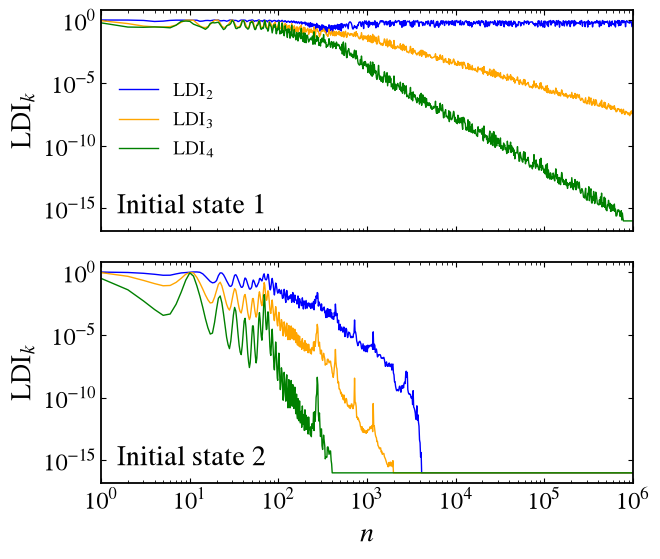

In [242]:
colors = ["blue", "orange", "green"]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)
for i in range(len(initial_states)):
    for j, k in enumerate(k_values):
        ax[i].loglog(
            sample_times,
            np.maximum(ldi_histories[i, :, j], tol),
            color=colors[j],
            label=rf"$\mathrm{{LDI}}_{k}$",
        )
    ax[i].set_ylabel(r"$\mathrm{LDI}_k$")
    ax[i].text(0.03, 0.08, f"Initial state {i + 1}", transform=ax[i].transAxes)
ax[0].legend(frameon=False, ncol=1)
ax[1].set_xlim(1, total_time)
ax[1].set_xlabel("$n$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/4d_symplectic_map_ldi.png",
    dpi=400,
    bbox_inches="tight",
)

For the same normalized deviation vectors, $\mathrm{GALI}_k=\mathrm{LDI}_k$, as shown by [Sales, Leonel, and Antonopoulos (2026)](https://doi.org/10.1016/j.chaos.2026.117884). The two indicators compute the same volume using different matrix factorizations.

### Benchmarking the formulations

In [248]:
from time import perf_counter

benchmark_time = 100_000
benchmark_repeats = 100
benchmark_state = initial_states[0]
benchmark_labels = ["SALI"] + [f"GALI {method.replace('_', '-')}" for method in gali_methods] + ["LDI SVD"]
benchmark_times = np.empty((len(benchmark_labels), benchmark_repeats))

system.SALI(u=benchmark_state, total_time=1, tol=0.0, seed=seed)
for method in gali_methods:
    system.GALI(u=benchmark_state, total_time=1, k=2, method=method, tol=0.0, seed=seed)
system.LDI(u=benchmark_state, total_time=1, k=2, tol=0.0, seed=seed)

for repeat in range(benchmark_repeats):
    start = perf_counter()
    system.SALI(
        u=benchmark_state,
        total_time=benchmark_time,
        tol=0.0,
        seed=seed,
    )
    benchmark_times[0, repeat] = perf_counter() - start

    for i, method in enumerate(gali_methods):
        start = perf_counter()
        system.GALI(
            u=benchmark_state,
            total_time=benchmark_time,
            k=2,
            method=method,
            tol=0.0,
            seed=seed,
        )
        benchmark_times[i + 1, repeat] = perf_counter() - start

    start = perf_counter()
    system.LDI(
        u=benchmark_state,
        total_time=benchmark_time,
        k=2,
        tol=0.0,
        seed=seed,
    )
    benchmark_times[-1, repeat] = perf_counter() - start

mean_times = np.mean(benchmark_times, axis=1)
std_times = np.std(benchmark_times, axis=1, ddof=1)

<Figure size 640x480 with 0 Axes>

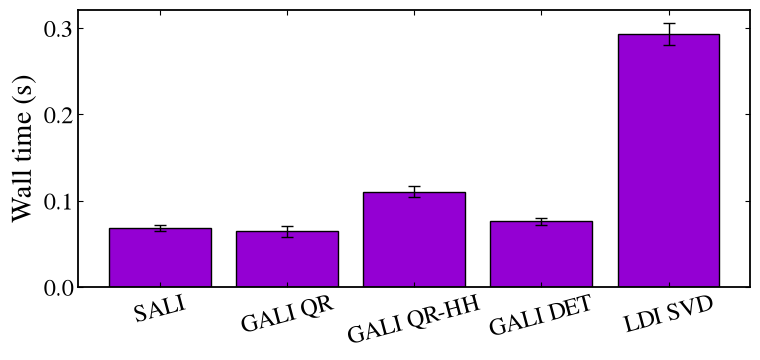

In [249]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    benchmark_labels,
    mean_times,
    yerr=std_times,
    color="darkviolet",
    edgecolor="black",
    linewidth=1.0,
    capsize=4,
)
ax.set_ylabel("Wall time (s)")
ax.tick_params(axis="x", labelrotation=15)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/4d_symplectic_map_alignment_benchmark.png",
    dpi=400,
    bbox_inches="tight",
)

## Weighted Birkhoff average

The weighted Birkhoff average replaces the uniform weights of an ordinary time average by a smooth bump that suppresses contributions near both ends of the trajectory. For sufficiently smooth quasiperiodic dynamics and observables, it converges faster than any inverse power of the number of iterations. The method was introduced by [Das et al. (2016)](https://doi.org/10.1209/0295-5075/114/40005), developed further by [Das et al. (2017)](https://doi.org/10.1088/1361-6544/aa84c2), and its superconvergence was established by [Das and Yorke (2018)](https://doi.org/10.1088/1361-6544/aa99a0).

### The dig indicator

The $\mathrm{dig}$ indicator compares weighted averages over two consecutive trajectory windows. Large values indicate rapid convergence and are characteristic of well-resolved quasiperiodic trajectories. Small values indicate slow convergence and are characteristic of chaotic trajectories, although sticky motion may require longer windows. In `system.dig`, `total_time` covers both windows, so each window receives half of the post-transient iterations.

In [262]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="standard map")
system.set_parameters([1.5])

rng = np.random.default_rng(1312)
num_initial_conditions = 200
initial_states = rng.uniform(0.0, 1.0, size=(num_initial_conditions, 2))
total_time = 20_000

digs = np.array(
    [
        system.dig(
            u=initial_state,
            total_time=total_time,
        )
        for initial_state in initial_states
    ]
)

trajectory_time = 10_000
trajectories = system.trajectory(
    u=initial_states,
    total_time=trajectory_time,
).reshape(num_initial_conditions, trajectory_time, 2)

<Figure size 640x480 with 0 Axes>

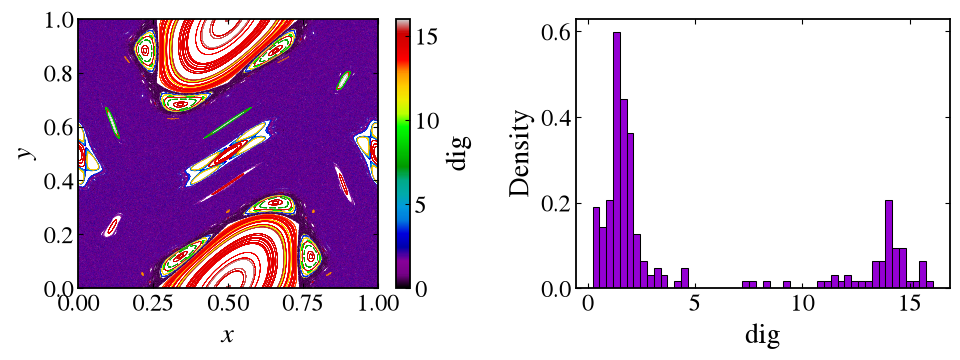

In [263]:
finite_digs = digs[np.isfinite(digs)]
trajectory_digs = np.repeat(digs, trajectory_time)

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
points = ax[0].scatter(
    trajectories[:, :, 0].ravel(),
    trajectories[:, :, 1].ravel(),
    c=trajectory_digs,
    s=0.1,
    edgecolor="none",
    cmap="nipy_spectral",
    vmin=0,
    vmax=16,
)
ax[0].set_xlim(0.0, 1.0)
ax[0].set_ylim(0.0, 1.0)
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
fig.colorbar(points, ax=ax[0], label=r"$\mathrm{dig}$")
ax[1].hist(
    finite_digs,
    bins=50,
    density=True,
    color="darkviolet",
    edgecolor="black",
    linewidth=0.75,
)
ax[1].set_xlabel(r"$\mathrm{dig}$")
ax[1].set_ylabel("Density")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_wba.png",
    dpi=400,
    bbox_inches="tight",
)

### Choosing an observable

The observable must accept a two-dimensional trajectory array and return a one-dimensional NumPy array with one value for each state. It should be smooth and nonconstant on the region being studied. A nearly constant or symmetry-degenerate observable can conceal the distinction of interest.

In [255]:
observable = lambda trajectory: np.sin(
    2.0 * np.pi * (trajectory[:, 0] + trajectory[:, 1])
)

custom_dig = system.dig(
    u=initial_states[0],
    total_time=total_time,
    func=observable,
)

## Recurrence time entropy

The recurrence time entropy is the Shannon entropy of the recurrence-time distribution estimated from the white vertical lines of a recurrence plot. Periodic motion has one recurrence time and zero RTE, quasiperiodic motion generally has a narrow distribution and low RTE, and chaotic motion generally has a broader distribution and higher RTE. Its recurrence-plot formulation and application to stickiness were developed by [Sales et al. (2023)](https://doi.org/10.1063/5.0140613).

### Threshold strategies

The new API selects the threshold strategy with `threshold_mode`. Use `"std"` to multiply the norm of the componentwise standard-deviation vector, `"direct"` to provide the recurrence radius in state-space units, or `"rr"` to provide a target off-diagonal recurrence rate between zero and one. The `metric` option controls distances between states, while `std_metric` controls how componentwise standard deviations are combined in `"std"` mode. The legacy `threshold_std` option is deprecated.

### Comparing parameter values

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="standard map")

num_initial_conditions = 250
np.random.seed(0)
x_initial = np.random.uniform(0.0, 1.0, num_initial_conditions)
y_initial = np.random.uniform(0.0, 1.0, num_initial_conditions)
initial_states = np.column_stack((x_initial, y_initial))
parameter_values = [0.9, 1.5, 3.6]
total_time = 10_000

rte_values = np.empty((len(parameter_values), num_initial_conditions))
trajectories = np.empty(
    (len(parameter_values), num_initial_conditions, total_time, 2)
)
for i, k in enumerate(parameter_values):
    for j, initial_state in enumerate(initial_states):
        rte_values[i, j] = system.recurrence_time_entropy(
            u=initial_state,
            total_time=total_time,
            parameters=[k],
            threshold_mode="std",
            threshold=0.1,
            metric="supremum",
            std_metric="supremum",
        )

    trajectories[i] = system.trajectory(
        u=initial_states,
        total_time=total_time,
        parameters=[k],
    ).reshape(num_initial_conditions, total_time, 2)

<Figure size 640x480 with 0 Axes>

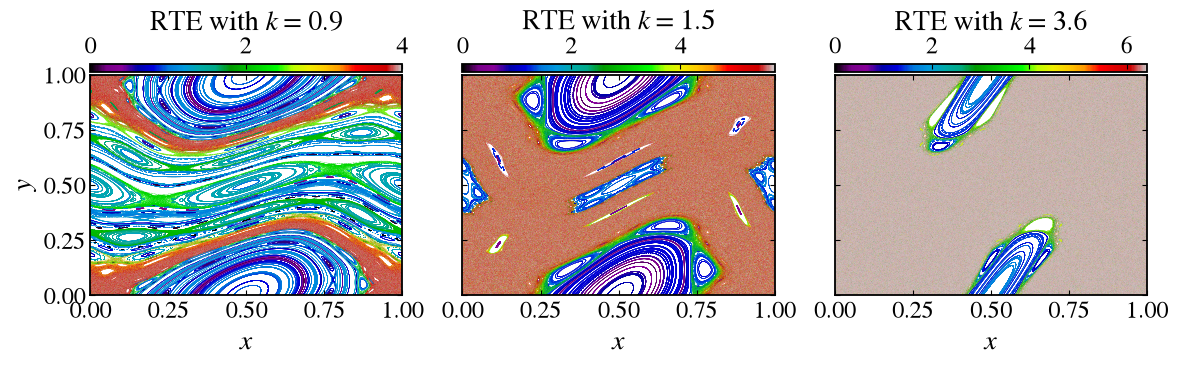

In [3]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for i, k in enumerate(parameter_values):
    trajectory_rte = np.repeat(rte_values[i], total_time)
    points = ax[i].scatter(
        trajectories[i, :, :, 0].ravel(),
        trajectories[i, :, :, 1].ravel(),
        c=trajectory_rte,
        s=0.05,
        edgecolor="none",
        cmap="nipy_spectral",
        vmin=0.0,
        vmax=rte_values[i].max(),
    )
    fig.colorbar(
        points,
        ax=ax[i],
        label=rf"RTE with $k={k:.1f}$",
        location="top",
        aspect=40,
        pad=0.01,
    )
    ax[i].set_xlim(0.0, 1.0)
    ax[i].set_ylim(0.0, 1.0)
    ax[i].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_rte.png",
    dpi=400,
    bbox_inches="tight",
)

### Finite-time RTE

`finite_time_recurrence_time_entropy` divides a trajectory into consecutive non-overlapping windows and returns one RTE value per complete window. With `return_points=True`, it also returns the state at the beginning of each window. A multimodal finite-time RTE distribution can reveal transitions between the chaotic sea and different sticky layers.

## Hurst exponent

The Hurst exponent was introduced by [Hurst (1951)](https://doi.org/10.1061/TACEAT.0006518) to quantify long-term dependence in time series. In the classical stochastic interpretation, $H=0.5$ indicates an uncorrelated process, $H>0.5$ indicates persistent correlations, and $H<0.5$ indicates antipersistent correlations. Its use for characterizing dynamical traps and the hierarchical structure of mixed phase spaces was proposed by [Borin (2024)](https://doi.org/10.1103/PhysRevE.110.064227).

### Rescaled-range analysis

For each block length $\ell$, the method divides the time series into complete non-overlapping blocks, calculates the range $R_\ell$ of the cumulative deviations from each block mean, and rescales it by the standard deviation $S_\ell$. The Hurst exponent is the slope of the linear fit $\ln\langle R/S\rangle_\ell=\ln C+H\ln\ell$. The `wmin` argument sets the smallest block length. The implementation tests every integer length from `wmin` through one less than half the effective trajectory length, ignores incomplete final blocks, and excludes blocks with zero standard deviation from the average.

### Coordinate-wise exponents

`hurst_exponent` accepts one initial state and returns one exponent for each coordinate. This differs from the two-dimensional adaptation in Borin (2024), where both coordinates in each subperiod are combined into one sequence. Here, $H_x$ and $H_y$ are estimated independently. The fitted finite-sample estimates are not clipped to $[0,1]$, and their values depend on the coordinate representation, trajectory length, fitted block lengths, and transient removal.

### Comparing parameter values

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="standard map")

num_initial_conditions = 250
np.random.seed(0)
x_initial = np.random.uniform(0.0, 1.0, num_initial_conditions)
y_initial = np.random.uniform(0.0, 1.0, num_initial_conditions)
initial_states = np.column_stack((x_initial, y_initial))
parameter_values = [0.9, 1.5, 3.6]
total_time = 10_000
wmin = 2

hurst_values = np.empty(
    (len(parameter_values), num_initial_conditions, 2)
)
trajectories = np.empty(
    (len(parameter_values), num_initial_conditions, total_time, 2)
)
for i, k in enumerate(parameter_values):
    for j, initial_state in enumerate(initial_states):
        hurst_values[i, j] = system.hurst_exponent(
            u=initial_state,
            total_time=total_time,
            parameters=[k],
            wmin=wmin,
        )

    trajectories[i] = system.trajectory(
        u=initial_states,
        total_time=total_time,
        parameters=[k],
    ).reshape(num_initial_conditions, total_time, 2)

<Figure size 640x480 with 0 Axes>

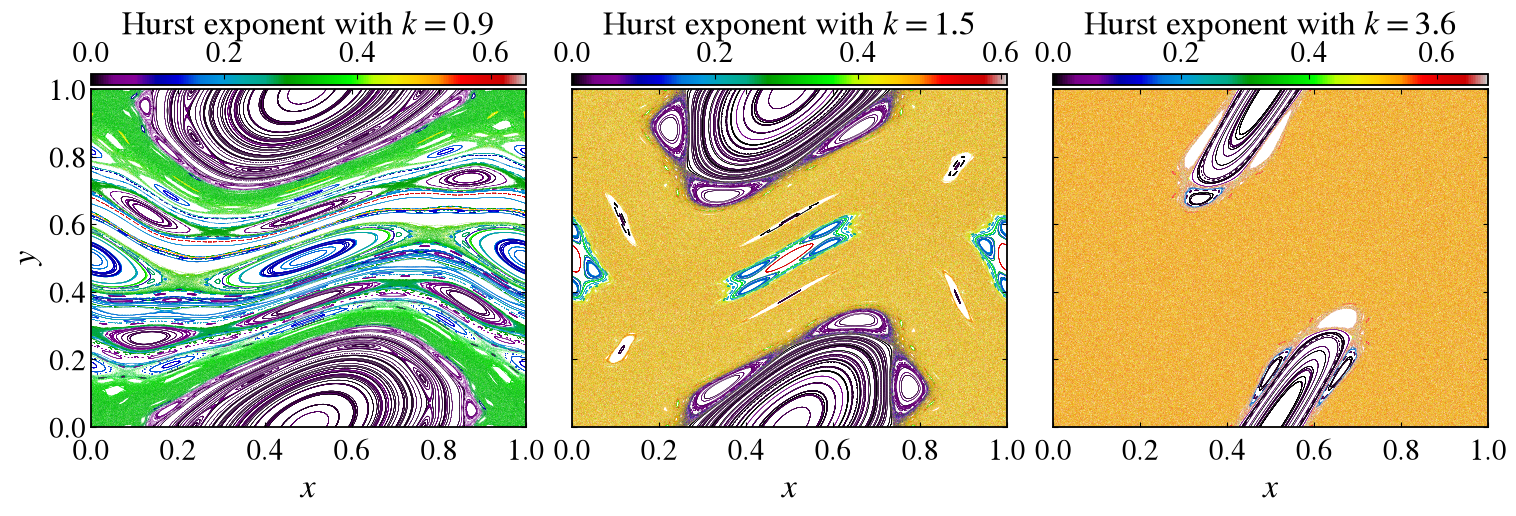

In [5]:
ps = PlotStyler(fontsize=24)
ps.apply_style()
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for axis in ax:
    ps.set_tick_padding(axis, pad_x=8)
for i, k in enumerate(parameter_values):
    trajectory_hurst = np.repeat(hurst_values[i, :, 0], total_time)
    points = ax[i].scatter(
        trajectories[i, :, :, 0].ravel(),
        trajectories[i, :, :, 1].ravel(),
        c=trajectory_hurst,
        s=0.05,
        edgecolor="none",
        cmap="nipy_spectral",
        vmin=0.0,
        vmax=hurst_values[i, :, 0].max(),
    )
    fig.colorbar(
        points,
        ax=ax[i],
        label=rf"Hurst exponent with $k = {k:.1f}$",
        location="top",
        aspect=40,
        pad=0.01,
    )
    ax[i].set_xlim(0.0, 1.0)
    ax[i].set_ylim(0.0, 1.0)
    ax[i].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig.tight_layout(pad=0.05)
plt.savefig(
    f"{path_figures}/standard_map_HE.png",
    dpi=400,
    bbox_inches="tight",
)

### Finite-time Hurst exponent

`finite_time_hurst_exponent` divides one trajectory into consecutive non-overlapping windows and returns one coordinate-wise estimate per complete window. With `return_points=True`, it also returns the final state of each window. A multimodal finite-time distribution can reveal visits to dynamically distinct regions, but its modes depend on the window length and fitted range.

# Periodic orbits and their manifolds

A fixed point of a map $\mathbf{x}_{n+1} = \mathbf{f}(\mathbf{x}_n)$ is a point $\mathbf{x}^*$ with $\mathbf{f}(\mathbf{x}^*) = \mathbf{x}^*$. A periodic orbit of period $p$ is a set of $p$ distinct points that map into one another and return to the start after $p$ iterations, so that $\mathbf{f}^p(\mathbf{x}^*) = \mathbf{x}^*$ for each point $\mathbf{x}^*$ in the orbit. A fixed point is the case $p = 1$.

The stability of an orbit follows from the eigenvalues of the monodromy matrix, the product of the Jacobian along the orbit. For a saddle, one eigenvalue lies inside the unit circle and one outside. The stable manifold is the set of points that approach the saddle under forward iteration, tangent to the eigenvector of the eigenvalue with magnitude below one; the unstable manifold is the set that approaches under backward iteration, tangent to the eigenvector of the eigenvalue with magnitude above one. These manifolds organize the surrounding dynamics, and their intersections are the origin of chaotic motion.

This page uses the standard map with $k = 1.5$ throughout.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="standard map")
system.set_parameters([1.5])

## Fixed points

The standard map has two fixed points, at $(0, 0)$ and $(0.5, 0)$. Use `classify_stability` to determine their type. It returns a dictionary with the `"classification"` label and the `"eigenvalues"` and `"eigenvectors"` of the monodromy matrix. This method is restricted to two-dimensional systems; in higher dimensions, use `eigenvalues_and_eigenvectors` and classify the multipliers yourself.

In [3]:
saddle = [0.0, 0.0]
center = [0.5, 0.0]

for point in (saddle, center):
    info = system.classify_stability(point, 1)
    print(point, info["classification"])
    print("eigenvalues:", info["eigenvalues"])

[0.0, 0.0] saddle
eigenvalues: [3.18614066+0.j 0.31385934+0.j]
[0.5, 0.0] elliptic (quasi-periodic)
eigenvalues: [0.25+0.96824584j 0.25-0.96824584j]


The point at $(0, 0)$ is a saddle: its multipliers are real, one larger than one and one smaller. The point at $(0.5, 0)$ is elliptic, with multipliers on the unit circle. Only the saddle has stable and unstable manifolds.

Compute them with `manifold`, which seeds points along the relevant eigendirection and iterates them.

In [4]:
unstable = system.manifold(saddle, 1, n_points=50000, iter_time=17, stability="unstable")
stable = system.manifold(saddle, 1, n_points=50000, iter_time=17, stability="stable")

Each call returns a tuple of two arrays, one for each branch of the manifold, seeded along the eigenvector and along its negative. `n_points` sets how many seed points are used and `iter_time` how many iterations evolve them; pass a tuple of two values to use different settings on the two branches. Computing the stable manifold iterates the map backward, so it requires a system with a backward mapping, as the built-in standard map has. The `manifold` method is implemented for two-dimensional maps only.

## Locating periodic orbits

Higher-period orbits are rarely known in closed form and must be located numerically. `find_periodic_orbit` provides three solvers, selected by the shape of the first argument:

- A **grid refinement** search: pass a 3D array of shape `(grid_size_x, grid_size_y, 2)`. It scans a rectangular region for near-periodic points and contracts around them. It needs no initial guess but is restricted to two-dimensional systems.
- A **symmetry-line** search: pass a 1D array of coordinates together with a `symmetry_line` function. This is the same refinement restricted to a curve, also two-dimensional only.
- **Newton's method**: pass a 1D initial guess. It refines a single point, works in any dimension, and converges quadratically, but only from a guess already close to an orbit.

The searches are global and slow; Newton is local and fast. A common pattern in two dimensions is to locate an orbit roughly with a search and then refine it with Newton. Two related methods help along the way: `period` estimates the period of an orbit from its recurrences, and `is_periodic` tests whether a point belongs to an orbit of a given period.

## Period-2 orbits

The standard map has an elliptic and a hyperbolic orbit of period 2. The elliptic orbit lies on the symmetry line $x = 0$, so it can be found with the symmetry-line search. Define the line as a function of the coordinate along it, sample a range that brackets the orbit, and search.

In [5]:
def symmetry_line(y, parameters):
    return 0.0 * np.ones_like(y)

points = np.linspace(0.4, 0.6, 10000)
elliptic_p2 = system.find_periodic_orbit(
    points,
    2,
    tolerance=2 / 10000,
    symmetry_line=symmetry_line,
    axis=1,
    verbose=True,
)

Iter 0: Δorbit=[0.         0.50007001], Δbounds=[0.0004     0.00027999], tol=2.00e-04
Iter 1: Δorbit=[0.00000000e+00 3.66680953e-05], Δbounds=[0.0002     0.00013336], tol=1.00e-04
Iter 2: Δorbit=[0.00000000e+00 1.66711911e-05], Δbounds=[1.00000000e-04 6.66709547e-05], tol=5.00e-05
Iter 3: Δorbit=[0.00000000e+00 8.33470281e-06], Δbounds=[5.00000000e-05 3.33372621e-05], tol=2.50e-05
Iter 4: Δorbit=[0.00000000e+00 4.16590749e-06], Δbounds=[2.50000000e-05 1.66715191e-05], tol=1.25e-05
Iter 5: Δorbit=[0.00000000e+00 2.08331464e-06], Δbounds=[1.25000000e-05 8.33503804e-06], tol=6.25e-06
Iter 6: Δorbit=[0.00000000e+00 1.04240075e-06], Δbounds=[6.25000000e-06 4.16769927e-06], tol=3.13e-06
Iter 7: Δorbit=[0.00000000e+00 5.20389292e-07], Δbounds=[3.1250000e-06 2.0838046e-06], tol=1.56e-06
Iter 8: Δorbit=[0.00000000e+00 2.60605826e-07], Δbounds=[1.56250000e-06 1.04191355e-06], tol=7.81e-07
Iter 9: Δorbit=[0.00000000e+00 1.30200118e-07], Δbounds=[7.81250000e-07 5.20953965e-07], tol=3.91e-07
Iter 1

Setting `verbose=True` prints the refinement history. At each step the search reports the change in the candidate orbit, the size of the search bounds, and the current tolerance, stopping when the orbit displacement falls below the convergence threshold. The remaining examples use `verbose=False` (the default). The `axis` argument states which coordinate parametrizes the symmetry line; here the line is traced by $y$, so `axis=1`. Confirm the result:

In [6]:
print(elliptic_p2, system.classify_stability(elliptic_p2, 2)["classification"])

[0.  0.5] elliptic (quasi-periodic)


The hyperbolic orbit sits between the two period-2 islands. Its location is not known in advance, so search a rectangle that encloses it with the grid refinement, then refine the result with Newton.

In [7]:
x = np.linspace(0.1, 0.3, 1000)
y = np.linspace(0.3, 0.55, 1000)
grid = np.stack(np.meshgrid(x, y, indexing="ij"), axis=-1)

saddle_p2 = system.find_periodic_orbit(grid, 2, tolerance=3 / 1000)
saddle_p2 = system.find_periodic_orbit(saddle_p2, 2, periods=[1.0, 1.0])

info = system.classify_stability(saddle_p2, 2)
print(saddle_p2, info["classification"])
print("eigenvalues:", info["eigenvalues"])

[0.19397649 0.38795298] saddle
eigenvalues: [4.09176343+0.00000000e+00j 0.24439341-3.96409986e-49j]


The `periods=[1.0, 1.0]` argument tells Newton that both coordinates of the standard map wrap with period 1. On such a torus, an orbit winding across the domain would otherwise look like a large residual; the wrapping periods let Newton measure the true distance. Use `np.inf` for any coordinate that does not wrap.

With the saddle located, compute its manifolds as before.

In [8]:
unstable_p2 = system.manifold(saddle_p2, 2, n_points=50000, iter_time=20, stability="unstable")
stable_p2 = system.manifold(saddle_p2, 2, n_points=50000, iter_time=20, stability="stable")

## Period-3 orbits

Around the central island, the Poincaré-Birkhoff theorem guarantees a chain of period-3 orbits, alternating elliptic and hyperbolic. Locate the hyperbolic orbit by scanning the whole unit square and refining with Newton.

In [9]:
x = np.linspace(0.0, 1.0, 400)
y = np.linspace(-0.5, 0.5, 400)
grid = np.stack(np.meshgrid(x, y, indexing="ij"), axis=-1)

saddle_p3 = system.find_periodic_orbit(grid, 3, tolerance=5e-3)
saddle_p3 = system.find_periodic_orbit(saddle_p3, 3, periods=[1.0, 1.0], prime_period=True)

info = system.classify_stability(saddle_p3, 3)
print(saddle_p3, info["classification"])
print("eigenvalues:", info["eigenvalues"])

[0.25377828 0.25377828] saddle
eigenvalues: [5.90789859+0.j 0.16926492+0.j]


The equation $\mathbf{f}^p(\mathbf{x}) = \mathbf{x}$ is also satisfied by points of any period dividing $p$, so a period-3 search can converge onto a fixed point. Setting `prime_period=True` makes Newton raise an error instead of returning such a point, so the result is guaranteed to have prime period 3. Verify it explicitly:

In [10]:
print("period:", system.period(saddle_p3, 20000))
print("is period 3:", system.is_periodic(saddle_p3, 3))
print("is period 1:", system.is_periodic(saddle_p3, 1))

period: 3
is period 3: True
is period 1: False


The elliptic orbit sits at the center of one of the period-3 islands. A guess near a visible island is enough for Newton:

In [11]:
elliptic_p3 = system.find_periodic_orbit([0.5, 0.38], 3, periods=[1.0, 1.0], prime_period=True)
print(elliptic_p3, system.classify_stability(elliptic_p3, 3)["classification"])

[0.5        0.38569696] elliptic (quasi-periodic)


Finally, compute the manifolds of the period-3 saddle.

In [12]:
unstable_p3 = system.manifold(saddle_p3, 3, n_points=50000, iter_time=22, stability="unstable")
stable_p3 = system.manifold(saddle_p3, 3, n_points=50000, iter_time=22, stability="stable")

## Visualizing the orbits and manifolds

The figure below collects the three orbit families over a chaotic trajectory that fills the surrounding stochastic layer. Saddles are drawn as circles and elliptic points as squares, colored by period, with each saddle's stable and unstable manifolds in matching shades. To place every point of an orbit, iterate its representative point with `trajectory`.

<Figure size 640x480 with 0 Axes>

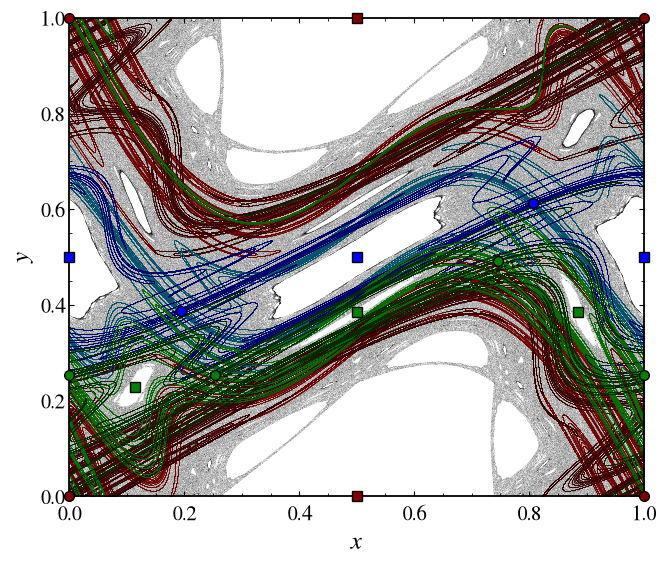

In [13]:
chaotic = system.trajectory([0.05, 0.05], 2_000_000)


def plot_manifold(ax, branches, color):
    for branch in branches:
        ax.plot(branch[:, 0], branch[:, 1], "o", markersize=0.4, color=color)


def plot_orbit(ax, point, period, marker, color, tol=1e-9):
    orbit = system.trajectory(point, period)
    images = []
    for x, y in orbit:
        xs = {0.0, 1.0} if (abs(x) < tol or abs(x - 1.0) < tol) else {x}
        ys = {0.0, 1.0} if (abs(y) < tol or abs(y - 1.0) < tol) else {y}
        for xi in xs:
            for yi in ys:
                images.append((xi, yi))
    images = np.array(images)
    ax.plot(
        images[:, 0], images[:, 1], marker, color=color, markersize=7,
        markeredgewidth=1, markeredgecolor="black", clip_on=False, zorder=10,
    )


ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0, minor_ticks_visible=True)
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 6))
ps.set_tick_padding(ax, pad_x=6)

ax.plot(chaotic[:, 0], chaotic[:, 1], "ko")

plot_manifold(ax, stable, "red")
plot_manifold(ax, unstable, "maroon")
plot_manifold(ax, stable_p2, "deepskyblue")
plot_manifold(ax, unstable_p2, "blue")
plot_manifold(ax, stable_p3, "lime")
plot_manifold(ax, unstable_p3, "darkgreen")

plot_orbit(ax, saddle, 1, "o", "maroon")
plot_orbit(ax, center, 1, "s", "maroon")
plot_orbit(ax, saddle_p2, 2, "o", "blue")
plot_orbit(ax, elliptic_p2, 2, "s", "blue")
plot_orbit(ax, saddle_p3, 3, "o", "green")
plot_orbit(ax, elliptic_p3, 3, "s", "green")

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
fig.tight_layout()
plt.savefig(f"{path_figures}/standard_map_manifolds.png", dpi=400, bbox_inches="tight")

**Note.** The `manifold` method and the grid-refinement and symmetry-line searches of `find_periodic_orbit` are implemented for two-dimensional maps only; Newton's method works in any dimension.

Generalizing the manifold calculation to higher-dimensional maps is planned. We also plan to implement the planar-map manifold tracing of D. Ciro, I. L. Caldas, R. L. Viana, and T. E. Evans, *Efficient manifolds tracing for planar maps*, [Chaos 28, 093106 (2018)](https://doi.org/10.1063/1.5027698), which decomposes the manifold into primary segments traced with an adaptive mapping-refinement scheme, together with a normal-displacement approximation whose cost decreases with manifold length.

# Escape dynamics

`escape_analysis` follows one initial condition until it leaves a bounded region or enters a hole. It returns `(escape_index, escape_time)`. With `escape="exiting"`, the index identifies the first boundary crossed. With `escape="entering"`, it identifies the first hole entered. A trajectory that does not escape within `max_time` returns `(-1, max_time)`, which is a censored observation rather than proof that it never escapes.

## Leaving a bounded region

The built-in Leonel map expects the parameters `[epsilon, gamma]`. Its survival probability and the transition from exponential escape to slower sticky tails were studied by [Borin, Livorati, and Leonel (2023)](https://doi.org/10.1016/j.chaos.2023.113965).

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

system = dds(model="leonel map")

epsilon_values = [1e-4, 1e-3, 1e-2]
gamma = 1.0
total_time = 1_000_000
initial_state = [np.pi, 1e-10]

trajectories = [
    system.trajectory(
        u=initial_state,
        total_time=total_time,
        parameters=[epsilon, gamma],
    )
    for epsilon in epsilon_values
]

<Figure size 640x480 with 0 Axes>

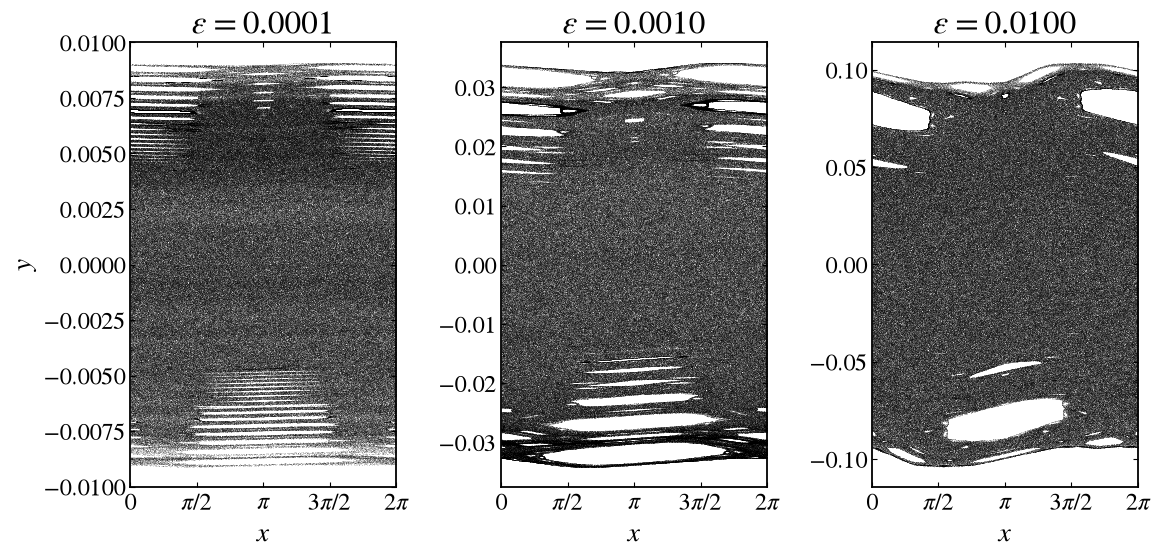

In [29]:

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 3, figsize=(12, 6), sharex=True)
for i, epsilon in enumerate(epsilon_values):
    ax[i].plot(
        trajectories[i][:, 0],
        trajectories[i][:, 1],
        "ko",
        markersize=0.2,
        markeredgewidth=0.0,
    )
    ax[i].set_title(rf"$\varepsilon={epsilon:.4f}$")
    ax[i].set_xlabel("$x$")
    ax[i].set_xlim(0.0, 2.0 * np.pi)
ax[0].set_ylabel("$y$")
ax[0].set_xticks(
    [0.0, np.pi / 2.0, np.pi, 3.0 * np.pi / 2.0, 2.0 * np.pi],
    [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"],
)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/leonel_map_trajectory.png",
    dpi=400,
    bbox_inches="tight",
)

Define the bounded region as $(x,y)\in[0,2\pi]\times[-y_{\mathrm{esc}},y_{\mathrm{esc}}]$. Because $x$ is represented modulo $2\pi$, trajectories can leave only through the lower or upper $y$ boundary, whose face indices are 2 and 3.

In [34]:
system.set_parameters([1e-3, 1.0])

max_time = 1_000_000
num_initial_conditions = 100_000
np.random.seed(13)
x_initial = np.random.uniform(
    0.0,
    2.0 * np.pi,
    num_initial_conditions,
)
y_initial = np.random.uniform(
    -1e-14,
    1e-14,
    num_initial_conditions,
)
initial_states = np.column_stack((x_initial, y_initial))
escape_thresholds = np.logspace(np.log10(1e-3), np.log10(0.025), 25)

escape_results = np.empty(
    (len(escape_thresholds), num_initial_conditions, 2),
    dtype=np.int64,
)
for i, escape_threshold in enumerate(escape_thresholds):
    bounded_region = np.array(
        [
            [0.0, 2.0 * np.pi],
            [-escape_threshold, escape_threshold],
        ]
    )
    escape_results[i] = np.array(
        [
            system.escape_analysis(
                u=initial_state,
                max_time=max_time,
                exits=bounded_region,
                escape="exiting",
            )
            for initial_state in initial_states
        ],
        dtype=np.int64,
    )

<Figure size 640x480 with 0 Axes>

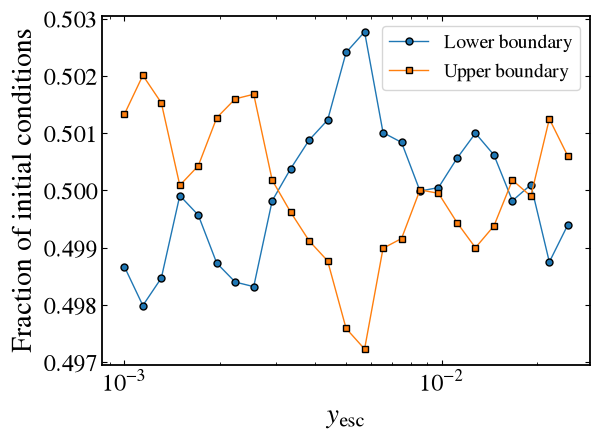

In [35]:
lower_fraction = np.mean(escape_results[:, :, 0] == 2, axis=1)
upper_fraction = np.mean(escape_results[:, :, 0] == 3, axis=1)

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots()
ax.plot(escape_thresholds, lower_fraction, "o-", label="Lower boundary")
ax.plot(escape_thresholds, upper_fraction, "s-", label="Upper boundary")
ax.set_xscale("log")
ax.set_xlabel(r"$y_{\mathrm{esc}}$")
ax.set_ylabel("Fraction of initial conditions")
ax.legend()
fig.tight_layout()
plt.savefig(
    f"{path_figures}/leonel_map_escape_basin.png",
    dpi=400,
    bbox_inches="tight",
)

## Survival probability

The survival probability is $P(n)=\Pr(T>n)$, the fraction of trajectories whose escape time is strictly greater than $n$. `survival_probability` evaluates it from an array of escape times. A straight segment on semilogarithmic axes is consistent with exponential escape, while a straight segment on logarithmic axes is consistent with a power law. Borin, Livorati, and Leonel found exponential survival in a fully chaotic region and a slower late-time decay when the region included stability islands, identifying the change as a signature of stickiness.

In [37]:
survival_times = []
survival_probabilities = []
for i in range(len(escape_thresholds)):
    times, probability = system.survival_probability(
        escape_times=escape_results[i, :, 1],
        max_time=max_time,
        min_time=1,
        time_step=1,
    )
    survival_times.append(times)
    survival_probabilities.append(probability)

<Figure size 640x480 with 0 Axes>

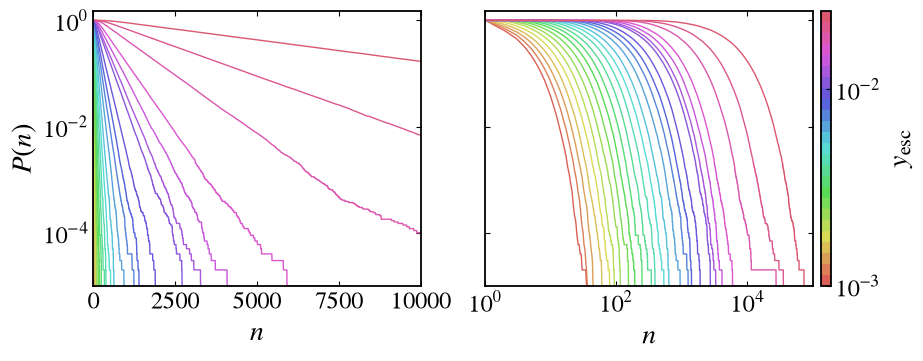

In [50]:
colors = sns.color_palette("hls", len(escape_thresholds))

norm = mpl.colors.LogNorm(
    vmin=escape_thresholds.min(),
    vmax=escape_thresholds.max(),
)

cmap = mpl.colors.ListedColormap(colors)
scalar_map = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, color in enumerate(colors):
    positive = survival_probabilities[i] > 0.0
    ax[0].plot(
        survival_times[i][positive],
        survival_probabilities[i][positive],
        color=color,
    )
    ax[1].plot(
        survival_times[i][positive],
        survival_probabilities[i][positive],
        color=color,
    )
ax[0].set_ylim(1 / num_initial_conditions, 1.5e0)
ax[0].set_xlim(0, 10000)
ax[0].set_yscale("log")
ax[0].set_xlabel("$n$")
ax[0].set_ylabel("$P(n)$")
ax[1].set_xlim(1e0, 1e5)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$n$")

fig.tight_layout()
colorbar = fig.colorbar(
    scalar_map,
    ax=ax,
    label=r"$y_{\mathrm{esc}}$",
    aspect=30,
    pad=0.01,
)
colorbar.ax.minorticks_off()

plt.savefig(
    f"{path_figures}/leonel_map_escape_analysis.png",
    dpi=400,
    bbox_inches="tight",
)

## Entering holes

For `escape="entering"`, each row of `exits` is the center of a hole and `hole_size` is its side length. The map was introduced by [Weiss (1991)](https://doi.org/10.1063/1.858068), while the following hole configuration was studied by [Souza et al. (2023)](https://doi.org/10.3390/e25081142). Increasing $k$ breaks the shearless transport barrier that initially separates the chaotic regions, causing the two escape basins to become increasingly mixed.

In [51]:
from joblib import Parallel, delayed
from matplotlib.colors import BoundaryNorm, ListedColormap
from numba import njit

@njit
def weiss_map(state, parameters):
    x, y = state
    k = parameters[0]
    y_new = y - k * np.sin(x)
    x_new = (
        x + k * (y_new**2 - 1.0) + np.pi
    ) % (2.0 * np.pi) - np.pi
    return np.array([x_new, y_new])

system = dds(
    mapping=weiss_map,
    system_dimension=2,
    number_of_parameters=1,
)

hole_centers = np.array(
    [
        [0.0, -1.1],
        [np.pi - 0.1, 1.0],
    ]
)
hole_size = 0.2
parameter_values = [0.5, 0.55, 0.60, 0.70]
max_time = 10_000

grid_size = 750
x_values = np.linspace(-np.pi, np.pi, grid_size)
y_values = np.linspace(-np.pi, np.pi, grid_size)
x_grid, y_grid = np.meshgrid(
    x_values,
    y_values,
    indexing="ij",
)
initial_states = np.column_stack((x_grid.ravel(), y_grid.ravel()))

In [52]:
escape_results = np.empty(
    (len(parameter_values), grid_size, grid_size, 2),
    dtype=np.int64,
)
for i, k in enumerate(parameter_values):
    result = Parallel(n_jobs=-1)(
        delayed(system.escape_analysis)(
            u=initial_state,
            max_time=max_time,
            exits=hole_centers,
            parameters=[k],
            escape="entering",
            hole_size=hole_size,
        )
        for initial_state in initial_states
    )
    escape_results[i] = np.asarray(
        result,
        dtype=np.int64,
    ).reshape(grid_size, grid_size, 2)

<Figure size 640x480 with 0 Axes>

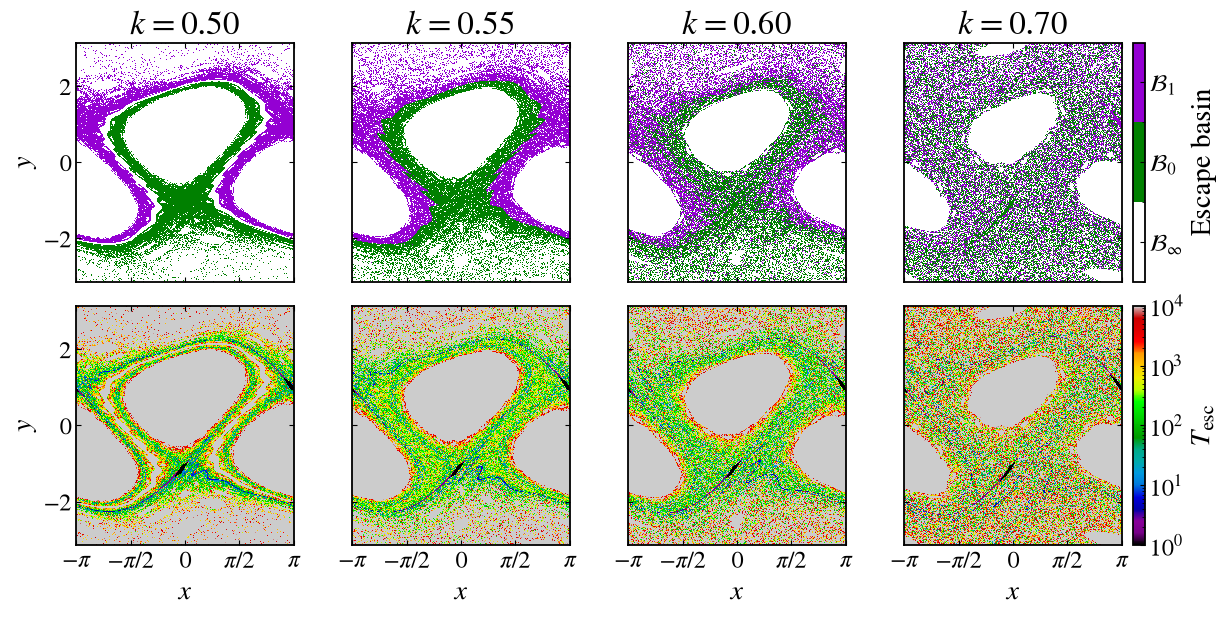

In [59]:
basin_colors = ["white", "green", "darkviolet"]
basin_cmap = ListedColormap(basin_colors)
basin_norm = BoundaryNorm(
    boundaries=[-1.5, -0.5, 0.5, 1.5],
    ncolors=len(basin_colors),
)

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(
    2,
    len(parameter_values),
    figsize=(12, 6),
    sharex=True,
    sharey=True,
)
fig.tight_layout(h_pad=0)
for i, k in enumerate(parameter_values):
    basin_plot = ax[0, i].pcolormesh(
        x_grid,
        y_grid,
        escape_results[i, :, :, 0],
        cmap=basin_cmap,
        norm=basin_norm,
        shading="auto",
    )
    time_plot = ax[1, i].pcolormesh(
        x_grid,
        y_grid,
        escape_results[i, :, :, 1],
        cmap="nipy_spectral",
        norm=mpl.colors.LogNorm(vmin=1, vmax=max_time),
        shading="auto",
    )
    ax[0, i].set_title(rf"$k={k:.2f}$")
    ax[1, i].set_xlabel("$x$")
ax[0, 0].set_ylabel("$y$")
ax[1, 0].set_ylabel("$y$")
ax[1, 0].set_xticks(
    [-np.pi, -np.pi / 2.0, 0.0, np.pi / 2.0, np.pi],
    [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"],
)
basin_colorbar = fig.colorbar(
    basin_plot,
    ax=ax[0, :],
    ticks=[-1, 0, 1],
    fraction=0.02,
    pad=0.01,
)
basin_colorbar.set_label("Escape basin")
basin_colorbar.set_ticklabels(
    [r"$\mathcal{B}_{\infty}$", r"$\mathcal{B}_0$", r"$\mathcal{B}_1$"]
)

fig.colorbar(
    time_plot,
    ax=ax[1, :],
    label=r"$T_{\mathrm{esc}}$",
    fraction=0.02,
    pad=0.01,
)

plt.savefig(
    f"{path_figures}/weiss_map_escape_analysis.png",
    dpi=400,
    bbox_inches="tight",
)

## Basin entropy

The basin entropy introduced by [Daza et al. (2016)](https://doi.org/10.1038/srep31416) measures final-state uncertainty at a chosen spatial resolution. Souza et al. applied it to the Weiss-map escape basins and identified shearless-barrier breakup from the onset of nonzero basin entropy. `BasinMetrics.basin_entropy` returns the basin entropy $S_b$ and boundary basin entropy $S_{bb}$. Here, the nonescaping label $\mathcal{B}_{\infty}$ remains a distinct outcome, so the values depend on `max_time` as well as the spatial partition and hole definition.

In [57]:
from pynamicalsys import BasinMetrics

points_per_box = 5
entropy_values = np.empty((len(parameter_values), 2))
for i in range(len(parameter_values)):
    basin = escape_results[i, :, :, 0]
    metrics = BasinMetrics(basin)
    entropy_values[i] = metrics.basin_entropy(
        n=points_per_box,
        log_base=2,
    )
    print(entropy_values[i])

[0.29369034 0.58467817]
[0.50049351 0.71142232]
[0.94166822 1.21774441]
[1.21077098 1.46661358]


# Transport

Transport asks how orbits move through phase space: how fast a single orbit drifts, and how an ensemble of initial conditions spreads. In an area-preserving map the answer is rarely simple diffusion. Invariant curves block the spreading, and orbits stick for long stretches near the islands, so the mean squared displacement can grow faster or slower than the linear-in-time law of normal diffusion. This page collects the tools **pynamicalsys** provides for measuring transport, using the standard map throughout.

Two settings of the standard map appear here. On the torus, both coordinates are taken modulo one, the phase space is bounded, and an orbit returns to its starting neighborhood again and again; this is the setting for the rotation number and for recurrence times. The `unbounded standard map` lifts the action off the torus, keeping only the angle modulo one, so the action is free to diffuse; this is the setting for the diffusion measures.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds, PlotStyler

## Rotation number

The rotation number of an orbit is the mean advance of the angle per iteration, the rate at which the orbit winds around the cylinder. Compute it with `rotation_number`, which averages the wrapped increment of the first coordinate over `total_time` iterations. For the orbit below it is close to $1/3$, so the angle advances by about a third of a turn each step:

In [61]:
system = dds(model="standard map")
system.set_parameters([0.7])
print(system.rotation_number([0.15, 0.30], 20000))

0.3333297272339906


Sweeping the initial action traces the rotation number across the phase space. Below the critical parameter most orbits lie on invariant curves and the rotation number increases with the action, but at rational values it locks onto a resonance and stays flat over a range of initial conditions, the mode-locking that produces a staircase:

<Figure size 640x480 with 0 Axes>

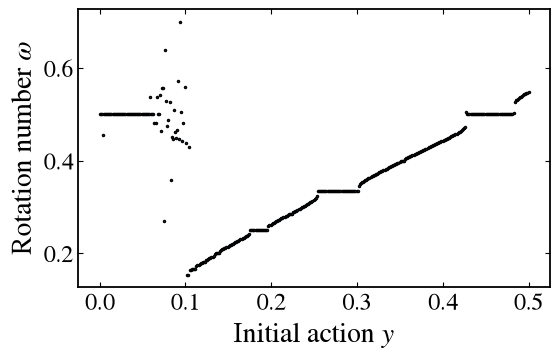

In [ ]:
system.set_parameters([0.7])
actions = np.linspace(0.0, 0.5, 400)
rotation = np.array([system.rotation_number([0.15, y], 20000) for y in actions])

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(actions, rotation, "o", markersize=1.5)
ax.set_xlabel("Initial action $y$")
ax.set_ylabel(r"Rotation number $\omega$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_rotation_number.png", dpi=400, bbox_inches="tight"
)

## Diffusion of an ensemble

When the action is free to grow, an ensemble of initial conditions spreads as it is iterated. The central quantity is the mean squared displacement of the action,

$$\mathrm{MSD}(n) = \left\langle \left(y_n - y_0\right)^2 \right\rangle,$$

averaged over the ensemble. Normal diffusion means $\mathrm{MSD}(n) \sim 2 D n$, a straight line of slope one on log-log axes; anomalous transport means $\mathrm{MSD}(n) \sim n^{\gamma}$ with $\gamma \neq 1$.

Build an ensemble on the `unbounded standard map`, spread across the angle at zero action, and follow its mean squared displacement with `mean_squared_displacement`. By default the displacement is measured along `axis=1`, the action:

In [20]:
system = dds(model="unbounded standard map")

rng = np.random.default_rng(0)
num_ic = 30 * 30
x0 = np.random.uniform(0, 1, num_ic)
y0 = np.random.uniform(0, 1, num_ic)
initial_conditions = np.column_stack([x0, y0])
total_time = int(1e6)

k1 = 5.0
system.set_parameters([k1])
msd_normal = system.mean_squared_displacement(initial_conditions, total_time, axis=1)

k2 = 6.75
system.set_parameters([k2])
msd_anomalous = system.mean_squared_displacement(initial_conditions, total_time, axis=1)

Each call returns a one-dimensional array of length `total_time`, the mean squared displacement at iterations $1$ to `total_time`. At $k = 5$ the growth is linear; at $k = 6.9$ the map has accelerator modes, small regions whose orbits step ballistically in the action, and the spreading is strongly superdiffusive:

<Figure size 640x480 with 0 Axes>

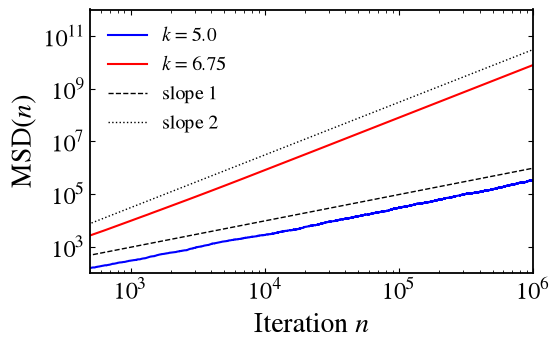

In [ ]:
time = np.arange(1, total_time + 1)
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(time, msd_normal, "b", label=f"$k = {k1}$", lw=1.5)
ax.loglog(time, msd_anomalous, "r", label=f"$k = {k2}$", lw=1.5)
ax.loglog(time, 3 * msd_normal[0] * time, "k--", lw=1, label=r"slope $1$")
ax.loglog(time, 0.03 * time**2, "k:", lw=1, label=r"slope $2$")
ax.set_xlabel("Iteration $n$")
ax.set_ylabel(r"$\mathrm{MSD}(n)$")
ax.set_ylim(1e2, 1e12)
ax.set_xlim(5e2, total_time)
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_diffusion_msd.png", dpi=400, bbox_inches="tight"
)

For the normal case, extract the diffusion coefficient with `diffusion_coefficient`, which reduces the ensemble spreading to the single number $D$ in $\mathrm{MSD}(n) \sim 2 D n$. If the successive angle kicks were uncorrelated, the action would perform a random walk with steps of variance $k^2 / (8\pi^2)$, giving the random-phase estimate $D_{\mathrm{QL}} = k^2 / (16\pi^2)$. At $k = 5$ the two agree closely:

In [65]:
system.set_parameters([5.0])
D = system.diffusion_coefficient(initial_conditions, total_time, axis=1)
print("measured D:", float(D))
print("random-phase D:", 5.0**2 / (16 * np.pi**2))

measured D: 0.1575283354658878
random-phase D: 0.15831434944115277


The diffusion coefficient is meaningful only when the spreading is normal. At $k = 7$ the same call returns a large number that grows with `total_time` rather than converging, which is the signal that the transport is anomalous and must be described by the exponent $\gamma$, not by $D$.

### Summaries of the ensemble

Several related methods summarize the same ensemble in different ways, all along the chosen `axis` and all optionally sampled at chosen `sample_times`. `average_in_time` returns the ensemble mean of the coordinate at each time, and `cumulative_average` its running cumulative version; for symmetric diffusion both stay near zero, confirming there is no net drift. `root_mean_squared` returns the root-mean-squared value of the coordinate at each time, the width of the ensemble, which grows as $\sqrt{n}$ under normal diffusion and is the square root of the mean squared displacement when there is no drift.

In [66]:
system.set_parameters([5.0])
mean = system.average_in_time(initial_conditions, total_time, axis=1)
rms = system.root_mean_squared(initial_conditions, total_time, axis=1)

Finally, `ensemble_time_average` returns one centered time-average per trajectory rather than a time series. Comparing the spread of these per-orbit averages against the ensemble average is a practical test of ergodicity: when time and ensemble averages disagree, the per-orbit values scatter widely.

In [67]:
eta = system.ensemble_time_average(initial_conditions, total_time, axis=1)
print(eta.shape, round(float(eta.mean()), 3), round(float(eta.std()), 3))

(5000,) 0.0 10.292


## Recurrence times and stickiness

On the torus the phase space is bounded and an orbit returns to any neighborhood infinitely often. The times between successive returns are not all alike: a chaotic orbit that wanders freely returns quickly and regularly, but one that sticks to the boundary of an island can stay away for enormous stretches. These long returns are the microscopic origin of anomalous transport.

`recurrence_times` records the times between successive returns of an orbit to an `eps`-neighborhood of its post-transient starting point:

In [79]:
system = dds(model="standard map")
system.set_parameters([1.5])
times = system.recurrence_times([0.2, 0.02], 1_000_000_000, eps=0.02)
print(times.size, times.min(), times.max(), times.mean())

561463 7.0 475852.0 1781.0521405684792


The returns span more than three orders of magnitude, from a few iterations to tens of thousands, and the mean sits far below the maximum. That heavy tail is the fingerprint of stickiness. Plotting the distribution on log-log axes shows the power-law decay that distinguishes a sticky orbit from the exponential decay of an ideal, fully chaotic one:

<Figure size 640x480 with 0 Axes>

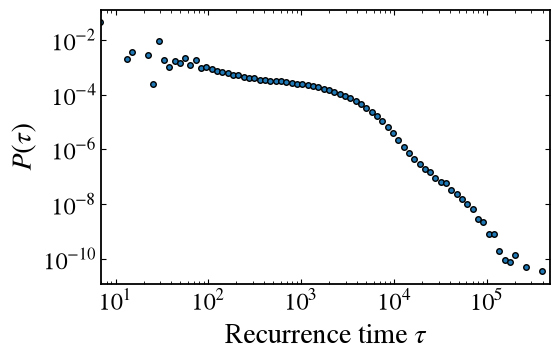

In [ ]:
counts, edges = np.histogram(
    times, bins=np.logspace(0, np.log10(times.max()), 100), density=True
)
centers = np.sqrt(edges[:-1] * edges[1:])

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(centers, counts, "o", markersize=4)
ax.set_xlabel(r"Recurrence time $\tau$")
ax.set_ylabel(r"$P(\tau)$")
ax.set_xlim(times.min(), times.max())
fig.tight_layout()
plt.savefig(
    f"{path_figures}/standard_map_recurrence_times.png", dpi=400, bbox_inches="tight"
)

The recurrence times measure how long an orbit stays near a region; the recurrence time entropy instead measures the complexity of the recurrence pattern itself. The two are complementary readings of the same recurrences.